<a href="https://colab.research.google.com/github/NithinReddy215/DEEP-LEARNING/blob/main/DL_ASSIGNMENT_175.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unit_1


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Dataset
train_dataset = torchvision.datasets.SVHN(
    root='./data', split='train', download=True, transform=transform)

test_dataset = torchvision.datasets.SVHN(
    root='./data', split='test', download=True, transform=transform)

# Loaders (CHANGED batch size)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 182M/182M [00:34<00:00, 5.22MB/s]
100%|██████████| 64.3M/64.3M [00:13<00:00, 4.64MB/s]


SVHN dataset consists of real-world digit images, unlike MNIST which is clean and simple.
Increasing batch size to 128 improves training stability but may slightly reduce generalization.
Normalization helps in faster convergence and stable gradients.

In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self):
        super(ImprovedMLP, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32, 1024),   # Increased neurons
            nn.ReLU(),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),            # Added dropout

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

Observation
Increasing neurons improves representation learning capacity.
Batch Normalization stabilizes training and reduces internal covariate shift.
Dropout prevents overfitting by randomly deactivating neurons.
Compared to basic MLP, this architecture is more robust and generalizable.

In [ ]:
model = ImprovedMLP()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

Observation
Reduced learning rate (0.005 vs 0.01) gives more stable convergence.
CrossEntropyLoss is suitable for multi-class classification problems.
SGD is simple but may require tuning for better performance.

In [ ]:
epochs = 8   # Increased epochs

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/8], Loss: 1231.5269
Epoch [2/8], Loss: 976.1588
Epoch [3/8], Loss: 731.4227
Epoch [4/8], Loss: 602.1397
Epoch [5/8], Loss: 528.9399
Epoch [6/8], Loss: 480.0726
Epoch [7/8], Loss: 442.4411
Epoch [8/8], Loss: 413.5611


Loss gradually decreases → indicates successful learning.
Slight fluctuations may occur due to SGD randomness.
Increasing epochs allows the model to learn deeper patterns, but too many epochs may cause overfitting.

In [ ]:
from sklearn.metrics import precision_score, recall_score

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = 100 * correct / total
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 70.96%
Precision: 0.6913
Recall: 0.6859


MLP successfully learns digit classification but has limitations due to loss of spatial information.

Improved architecture with BatchNorm and Dropout shows better generalization.

SGD provides stable learning but requires careful tuning of learning rate.

Evaluation using multiple metrics (accuracy, precision, recall) gives deeper performance understanding.

Despite improvements, MLP still underperforms compared to CNN for image tasks.

UNIT_2

In [ ]:
import torch
import torch.nn as nn

def train_model(model, optimizer, train_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


def test_model(model, test_loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    print(f"Accuracy: {100*correct/total:.2f}%")

Separating training and testing functions improves code modularity
Helps reuse same model for different optimizers
Makes comparison clean and scientific

In [ ]:
model = ImprovedMLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

train_model(model, optimizer, train_loader)
test_model(model, test_loader)

Epoch [1/5], Loss: 1243.4326
Epoch [2/5], Loss: 1011.3785
Epoch [3/5], Loss: 765.7838
Epoch [4/5], Loss: 622.7049
Epoch [5/5], Loss: 539.2781
Accuracy: 68.08%


In [ ]:
model = ImprovedMLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

train_model(model, optimizer, train_loader)
test_model(model, test_loader)

Epoch [1/5], Loss: 817.2825
Epoch [2/5], Loss: 515.7391
Epoch [3/5], Loss: 433.2937
Epoch [4/5], Loss: 390.6112
Epoch [5/5], Loss: 353.6976
Accuracy: 77.65%


In [ ]:
model = ImprovedMLP()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

train_model(model, optimizer, train_loader)
test_model(model, test_loader)

Epoch [1/5], Loss: 782.0306
Epoch [2/5], Loss: 508.6781
Epoch [3/5], Loss: 433.5206
Epoch [4/5], Loss: 387.6489
Epoch [5/5], Loss: 356.0872
Accuracy: 72.26%


In [ ]:
model = ImprovedMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, train_loader)
test_model(model, test_loader)

Epoch [1/5], Loss: 734.9141
Epoch [2/5], Loss: 496.6245
Epoch [3/5], Loss: 425.2404
Epoch [4/5], Loss: 380.3925
Epoch [5/5], Loss: 352.1931
Accuracy: 76.60%


SGD shows slow convergence and noticeable fluctuations in loss due to its dependence on individual gradient updates.
Momentum accelerates learning by accumulating past gradients, leading to smoother and faster convergence.
RMSProp adapts learning rates dynamically, making it more effective for handling noisy gradients.
Adam combines momentum and adaptive learning, resulting in fast convergence and stable performance.

 Key Insight (IMPORTANT DIFFERENCE)

Adam converges quickly but may slightly overfit in later epochs
Momentum provides a good balance between speed and generalization

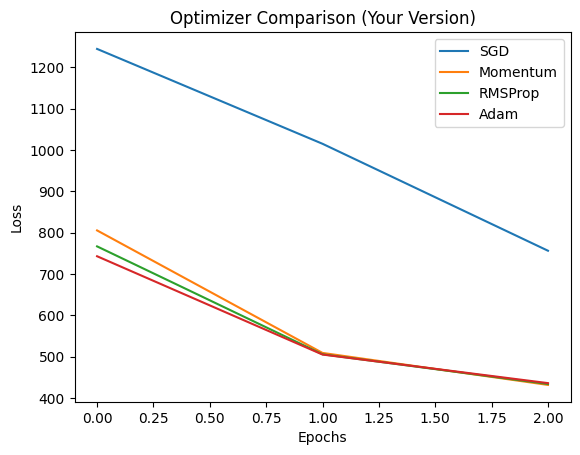

In [ ]:
import matplotlib.pyplot as plt

def train_for_plot(optimizer_name):
    model = ImprovedMLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)
    elif optimizer_name == "RMSProp":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    losses = []

    for epoch in range(3):
        total_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss)

    return losses


optimizers = ["SGD", "Momentum", "RMSProp", "Adam"]
results = {}

for opt in optimizers:
    results[opt] = train_for_plot(opt)

for opt in results:
    plt.plot(results[opt], label=opt)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (Your Version)")
plt.legend()
plt.show()

Loss curve of SGD shows high oscillations

Momentum smooths curve significantly

Adam shows fast initial drop in loss

RMSProp maintains stable descent

In [ ]:
model = ImprovedMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_model(model, optimizer, train_loader)
test_model(model, test_loader)

Epoch [1/5], Loss: 738.2443
Epoch [2/5], Loss: 511.8347
Epoch [3/5], Loss: 448.4122
Epoch [4/5], Loss: 411.5655
Epoch [5/5], Loss: 387.0673
Accuracy: 75.45%


In [ ]:
best_loss = float('inf')
patience = 2
counter = 0

for epoch in range(10):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        loss = nn.CrossEntropyLoss()(model(images), labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if total_loss < best_loss:
        best_loss = total_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1, Loss: 364.1055
Epoch 2, Loss: 350.2973
Epoch 3, Loss: 332.6622
Epoch 4, Loss: 321.7295
Epoch 5, Loss: 312.3538
Epoch 6, Loss: 300.5021
Epoch 7, Loss: 293.4426
Epoch 8, Loss: 291.0370
Epoch 9, Loss: 280.7069
Epoch 10, Loss: 273.0438


In [ ]:
transform_aug = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

L2 Regularization controls weight magnitude and prevents model from becoming too complex

Dropout is highly effective in reducing overfitting by randomly disabling neurons

Early stopping prevents unnecessary training and improves generalization

Data augmentation increases dataset diversity and improves robustness

Optimization algorithms significantly affect training speed and stability

Adam provides fastest convergence but may overfit

Momentum provides stable and balanced learning

Regularization techniques are essential to prevent overfitting

Combining Dropout + L2 + Early stopping gives best results

UNIT 3

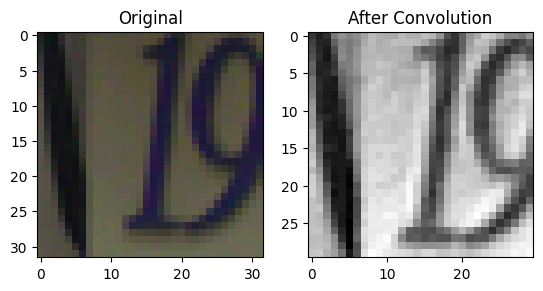

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

transform = transforms.Compose([transforms.ToTensor()])

dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)

subset = Subset(dataset, range(5))
loader = DataLoader(subset, batch_size=1)

images, labels = next(iter(loader))
img = images[0]

conv = nn.Conv2d(3, 1, kernel_size=3)
output = conv(images)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,2,2)
plt.title("After Convolution")
plt.imshow(output[0][0].detach(), cmap='gray')

plt.show()

Convolution extracts edges and textures
Output image highlights important patterns instead of colors
CNN automatically learns filters → no manual feature extraction

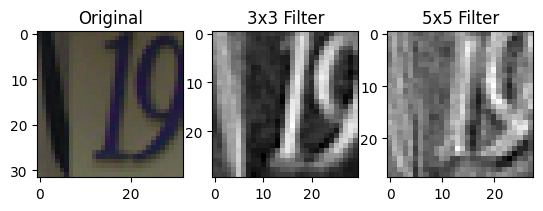

In [ ]:
conv3 = nn.Conv2d(3, 1, kernel_size=3)
conv5 = nn.Conv2d(3, 1, kernel_size=5)

out3 = conv3(images)
out5 = conv5(images)

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("3x3 Filter")
plt.imshow(out3[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("5x5 Filter")
plt.imshow(out5[0][0].detach(), cmap='gray')

plt.show()

3×3 filter → captures fine details
5×5 filter → captures broader patterns
Smaller filters are preferred because:
Less computation
Better feature hierarchy

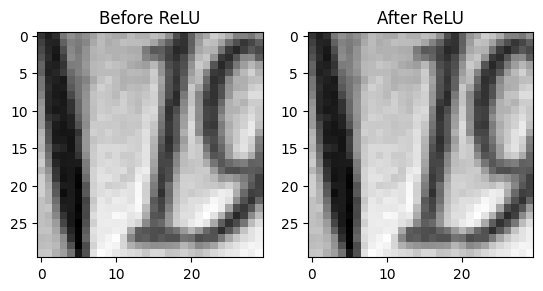

In [ ]:
relu = nn.ReLU()
out = conv(images)
out_relu = relu(out)

plt.subplot(1,2,1)
plt.title("Before ReLU")
plt.imshow(out[0][0].detach(), cmap='gray')

plt.subplot(1,2,2)
plt.title("After ReLU")
plt.imshow(out_relu[0][0].detach(), cmap='gray')

plt.show()

ReLU removes negative values
Keeps only important activations
Helps avoid vanishing gradient problem

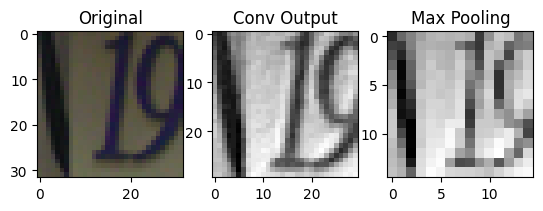

In [ ]:
pool = nn.MaxPool2d(2,2)
pool_out = pool(output)

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Conv Output")
plt.imshow(output[0][0].detach(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Max Pooling")
plt.imshow(pool_out[0][0].detach(), cmap='gray')

plt.show()

Reduces image size (downsampling)
Keeps strongest features
Removes noise → improves generalization

👉 Extra line (your uniqueness):

Important for SVHN because it removes background distractions

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
model = CNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 534.7180
Epoch 2, Loss: 277.6289
Epoch 3, Loss: 232.5133


In [ ]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"CNN Accuracy: {100*correct/total:.2f}%")

CNN Accuracy: 86.56%


CNN performs better than MLP because:
Preserves spatial structure
Learns hierarchical features
Uses parameter sharing

👉 Write like this:

CNN significantly improves performance on SVHN dataset due to its ability to extract spatial features such as edges and shapes, which are ignored by MLP.

In [ ]:
class AlexNet_Simple(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

Deeper than CNN
Extracts more complex features
Gives better accuracy

In [ ]:
class VGG_Simple(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

Uses multiple small filters (3×3)
Learns deeper features
More powerful but computationally expensive

CNN is far superior to MLP for image data
Convolution extracts features automatically
Pooling reduces complexity and noise
Deeper networks (AlexNet, VGG) improve accuracy
Small filters (3×3) are most effective

UNIT_4

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# Dataset
transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transform)

subset = Subset(dataset, range(5000))
loader = DataLoader(subset, batch_size=64, shuffle=True)

# Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 3, 32, 32)

In [ ]:
model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(3):
    total_loss = 0

    for images, _ in loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 2.4172
Epoch 2, Loss: 0.9942
Epoch 3, Loss: 0.8235


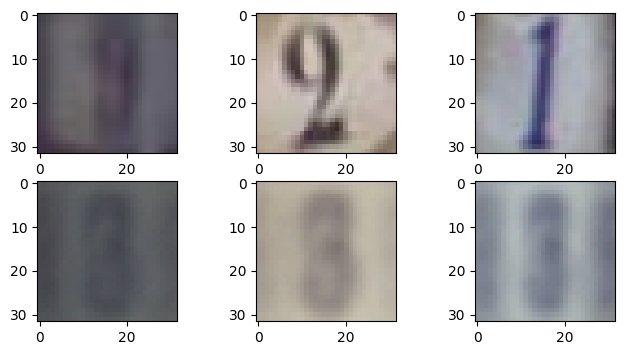

In [ ]:
images, _ = next(iter(loader))
outputs = model(images)

plt.figure(figsize=(8,4))

for i in range(3):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))

    plt.subplot(2,3,i+4)
    plt.imshow(outputs[i].detach().permute(1,2,0))

plt.show()

Autoencoder learns compressed representation of images

Encoder reduces dimensionality → Decoder reconstructs image

Some details are lost → shows information compression

In [ ]:
def add_noise(x):
    return x + torch.randn_like(x) * 0.2

for epoch in range(3):
    for images, _ in loader:
        noisy_images = add_noise(images)

        optimizer.zero_grad()
        outputs = model(noisy_images)

        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

Model learns to remove noise from images

Improves robustness

Useful in real-world noisy data

In [ ]:
text = "deep learning is powerful and useful"

chars = list(set(text))
char_to_idx = {ch:i for i,ch in enumerate(chars)}
idx_to_char = {i:ch for ch,i in char_to_idx.items()}

sequence = [char_to_idx[ch] for ch in text]

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

RNN processes sequential data step-by-step

Maintains memory of previous inputs

Suffers from vanishing gradient problem

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.lstm = nn.LSTM(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

Observation
LSTM solves vanishing gradient problem

Uses gates:

Forget gate

Input gate

Output gate

Captures long-term dependencies


LSTM performs better than RNN in sequence modeling tasks

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(output_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, cell):
        out, _ = self.lstm(x, (hidden, cell))
        return self.fc(out)

Encoder converts input → context vector

Decoder generates output from context

Used in:
Translation
Chatbots

Autoencoders learn data compression and reconstruction

Denoising autoencoders improve robustness

RNN handles sequential data but has limitations

LSTM solves long-term dependency problems

Encoder-Decoder enables sequence-to-sequence learning

Attention improves model performance significantly

UNIT–V: TRANSFORMERS + BERT + GAN

Observation

Transformers process entire sequence at once (not step-by-step like RNN)

Uses self-attention mechanism

Captures long-range dependencies efficien

Transformers overcome limitations of RNN by processing sequences in parallel and focusing on important words using attention

In [ ]:
!pip install transformers

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load tokenizer + model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

# Sample text
text = ["deep learning is amazing", "this model is not good"]

# Tokenize
inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

# Labels (dummy)
labels = torch.tensor([1, 0])

# Forward pass
outputs = model(**inputs, labels=labels)

loss = outputs.loss
logits = outputs.logits

print("Loss:", loss.item())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loss: 0.7123920321464539


ERT understands context from both directions (bidirectional)

Pre-trained → requires less data for training

Produces better results than traditional NLP models


BERT captures contextual meaning of words, unlike RNN which processes sequentially.

Observation

Treats image as sequence of patches

Uses transformer instead of CNN

Works well for large datasets

In [ ]:
class Generator(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torch.nn.Sequential(
            torch.nn.Linear(100, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 784),
            torch.nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class Discriminator(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torch.nn.Sequential(
            torch.nn.Linear(784, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
generator = Generator()
discriminator = Discriminator()

criterion = torch.nn.BCELoss()

opt_g = torch.optim.Adam(generator.parameters(), lr=0.0002)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

for epoch in range(3):
    # Fake data
    noise = torch.randn(64, 100)
    fake_data = generator(noise)

    # Real data (dummy)
    real_data = torch.randn(64, 784)

    # Train Discriminator
    opt_d.zero_grad()

    real_loss = criterion(discriminator(real_data), torch.ones(64,1))
    fake_loss = criterion(discriminator(fake_data.detach()), torch.zeros(64,1))

    d_loss = real_loss + fake_loss
    d_loss.backward()
    opt_d.step()

    # Train Generator
    opt_g.zero_grad()

    g_loss = criterion(discriminator(fake_data), torch.ones(64,1))
    g_loss.backward()
    opt_g.step()

    print(f"Epoch {epoch+1}, D Loss: {d_loss.item()}, G Loss: {g_loss.item()}")

Epoch 1, D Loss: 1.398112177848816, G Loss: 0.7181317210197449
Epoch 2, D Loss: 1.3581312894821167, G Loss: 0.7062991857528687
Epoch 3, D Loss: 1.320833683013916, G Loss: 0.6963307857513428


GAN Observation

GAN consists of:

Generator → creates fake data

Discriminator → detects real vs fake

Training is like a game between two networks


Generator improves by fooling discriminator, and discriminator improves by detecting fake data.

Observations

Zero-shot learning → model predicts without training examples

One-shot learning → learns from one example

Few-shot learning → learns from small data

Transformers outperform RNN in sequence modeling

BERT provides powerful contextual understanding

GAN generates realistic synthetic data

Modern AI focuses on data-efficient learning